In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt


def train_tensor4_reconstruction_gd(p: int,
                                    H: int,
                                    sigma2: float,
                                    T: float,
                                    num_epochs: int,
                                    batch_size: int,
                                    t_max=None,
                                    no_target: bool = True,
                                    device: str = "cuda:0",
                                    seed: int | None = None):
    """
    Full-batch GD for order-4 tensor reconstruction (shared CP factors),
    streaming indices without storing the p^4 grid.
    """

    # set seed if requested
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # time grid 
    if t_max is None:
        t_max = num_epochs
    t_arr, tau = np.linspace(0, t_max, num_epochs + 1, retstep=True)
   
    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    sigma = float(sigma2) ** 0.5

    # parameters
    u = nn.Parameter(torch.randn(H, p, device=dev) * sigma)

    # simple GD with LR = tau / T (if tau<0 then gradient ascent)
    optimizer = torch.optim.SGD([u], lr=abs(tau / T), maximize=(tau < 0))
    epoch_loss_hist = []

    # constants for index decoding
    N = p**4
    p1 = p
    p2 = p * p
    p3 = p * p * p

    for epoch in tqdm(range(1, num_epochs + 1)):
        epoch_loss = 0.0
        optimizer.zero_grad()

        # total number of batches to cover all p^4 entries
        num_batches = (N + batch_size - 1) // batch_size

        for b in range(num_batches):
            start = b * batch_size
            end = min(start + batch_size, N)
            B = end - start

            # linear indices [start, end)
            lin = torch.arange(start, end, device=dev, dtype=torch.long)

            # decode to (i,j,k,l)
            i_b = (lin // p3) % p
            j_b = (lin // p2) % p
            k_b = (lin // p1) % p
            l_b = lin % p1

            # forward: (H,B) -> (B,)
            pred = (u[:, i_b] * u[:, j_b] * u[:, k_b] * u[:, l_b]).sum(dim=0)

            # targets
            if no_target:
                tgt = torch.zeros_like(pred)
            else:
                tgt = ((i_b == j_b) & (j_b == k_b) & (k_b == l_b)).float()

            # batch loss
            loss = 0.5 * torch.sum((pred - tgt) ** 2)
            loss.backward()
            epoch_loss += float(loss.item())

        optimizer.step()
        epoch_loss_hist.append(epoch_loss)
        if epoch_loss / epoch_loss_hist[0] > 1.2:
            break

    return u.detach().cpu(), np.array(epoch_loss_hist), t_arr[:-1]


# Underparameterized $\nu = 4$

In [ ]:
loss_hists_under = []
p_list = [64,32,16]
L_0 = 1.0
t_max = 100.0
num_iters = 500
c = 0.25
batch_size = int(2**20)
for p in p_list:
    H = p//2
    sigma2 = (2*L_0/H/p**4)**0.25
    T = 24 * p**3 * sigma2**3 / c
    u,loss_hist,t_arr = train_tensor4_reconstruction_gd(p, H, sigma2, T, num_iters,batch_size,t_max=t_max,no_target=True)
    loss_hists_under.append(loss_hist)

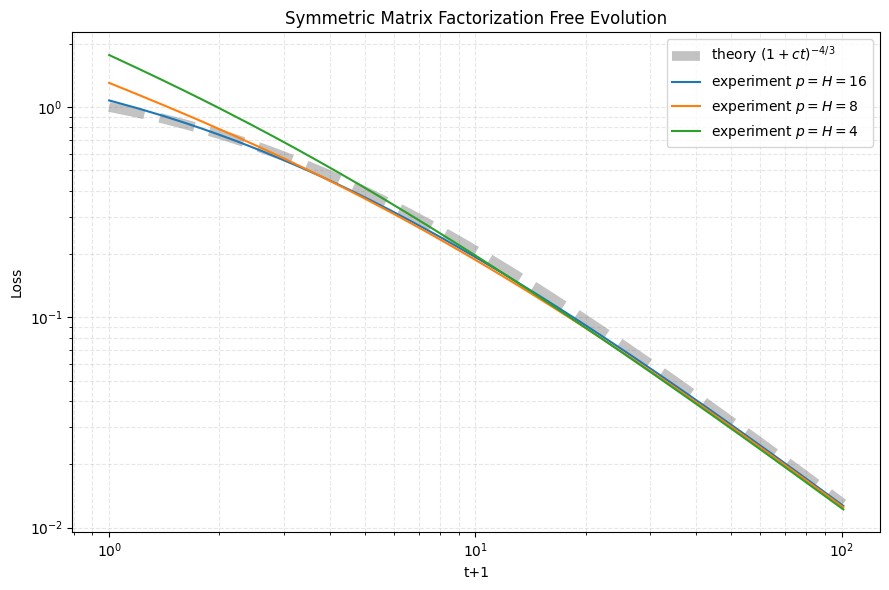

In [ ]:
plt.figure(figsize=(9, 6))
theory_loss = (1+c*t_arr)**(-4/3)
plt.plot(t_arr+1, theory_loss,label=f'theory $(1+ct)^{{-4/3}}$', color = 'dimgray',linestyle='--',linewidth=7,alpha=0.4)
for i,p in enumerate(p_list):
    H=p//2
    plt.plot(t_arr+1, loss_hists_under[i], label=f'experiment $p = H = {p}$')
    
#plt.ylim(-loss_curves[0].min()+p/2,-loss_curves[0].max()+p/2)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('t+1')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Symmetric $\\nu=4$ Free Evolution')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Typo in plot title

# Overparameterized $\nu=4$

In [ ]:
loss_hists_over = []
p_list = [16,8,4]
L_0 = 1.0
t_max = 100.0
num_iters = 500
c = 0.25
batch_size = int(2**15)
for p in p_list:
    H = int(p**3)
    sigma2 = (2*L_0/3/H**2/p**2)**0.25
    T = 72 * p * H * sigma2**3 / c
    u,loss_hist,t_arr = train_tensor4_reconstruction_gd(p, H, sigma2, T, num_iters,batch_size,t_max=t_max,no_target=True)
    loss_hists_over.append(loss_hist)

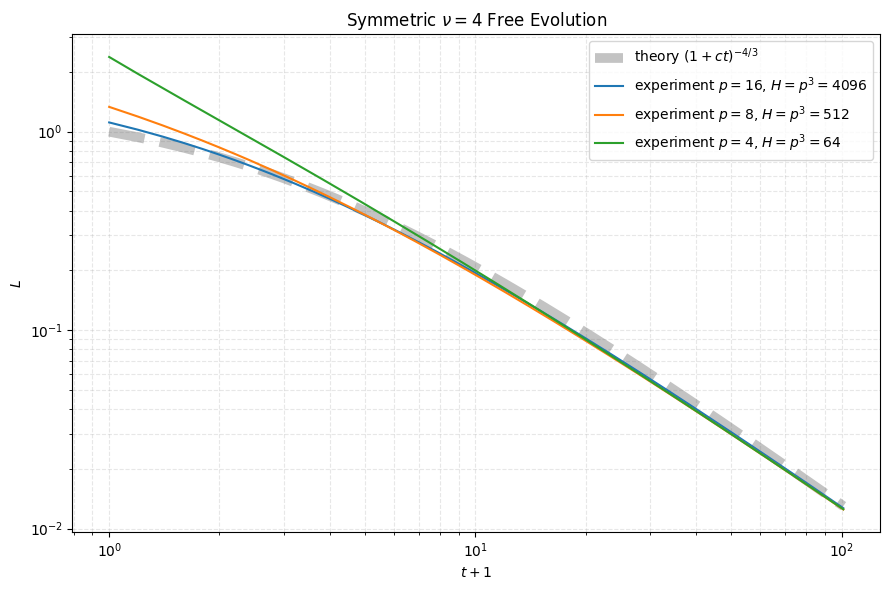

In [16]:
plt.figure(figsize=(9, 6))
num_iters=500
c = 0.25
t_max=100.0
t_arr = np.linspace(0.0,t_max,num_iters)
theory_loss = (1+c*t_arr)**(-4/3)
plt.plot(t_arr+1, theory_loss,label=f'theory $(1+ct)^{{-4/3}}$', color = 'dimgray',linestyle='--',linewidth=7,alpha=0.4)
for i,p in enumerate(p_list):
    H = int(p**3)
    plt.plot(t_arr+1, loss_hists_over[i], label=f'experiment $p = {p}$, $H = p^{3} = {H}$')
    
#plt.ylim(-loss_curves[0].min()+p/2,-loss_curves[0].max()+p/2)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$t+1$')
plt.ylabel('$L$')
plt.legend()
plt.title(f'Symmetric $\\nu=4$ Free Evolution')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()